### PROJET SPECIALISATION DATA SCIENCE - SMART CITY

![atut_logo](atut_logo.png)

Github du projet : https://github.com/ArielShadrac/AfricaTechUpTour-DataScience-Specialisation-2025-2026

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [40]:
# Configuration du rendu Seaborn
sns.set_style("whitegrid")
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option("display.max_columns", None)

In [41]:
# Chargement du dataset
df = pd.read_csv("dataset/smart_mobility_dataset.csv")
df.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


In [42]:
# Conversion de la colonne temporelle
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

In [43]:
print(f"Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Période : de {df['Timestamp'].min()} à  {df['Timestamp'].max()}")

Dataset chargé : 5,000 lignes × 15 colonnes
Période : de 2024-03-01 00:00:00 à  2024-03-18 08:35:00


### Analyse Exploratoire

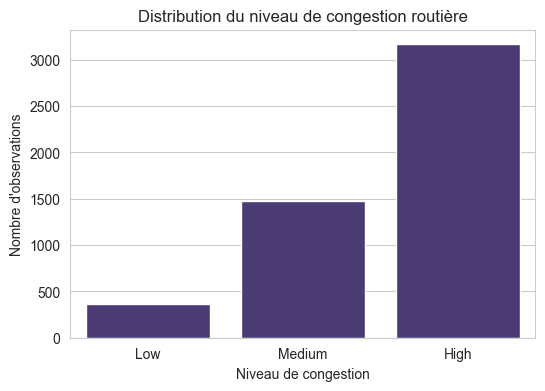

In [44]:
# Dsictrubution de la variable cible
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Traffic_Condition", order=['Low', 'Medium', 'High'])
plt.title("Distribution du niveau de congestion routière")
plt.xlabel("Niveau de congestion")
plt.ylabel("Nombre d'observations")
plt.show()

In [45]:
# Statistiques descriptives des variables numériques

num_cols = [
    "Vehicle_Count", "Traffic_Speed_kmh", "Road_Occupancy_%",
    "Sentiment_Score", "Ride_Sharing_Demand", "Parking_Availability",
    "Emission_Levels_g_km", "Energy_Consumption_L_h"
]

print(df[num_cols].describe().T)

                         count        mean         std        min         25%  \
Vehicle_Count           5000.0  153.921200   83.523342  10.000000   80.000000   
Traffic_Speed_kmh       5000.0   42.111096   21.707720   5.002789   23.195752   
Road_Occupancy_%        5000.0   54.748397   26.145238  10.005031   32.089653   
Sentiment_Score         5000.0   -0.005652    0.583790  -0.999819   -0.500154   
Ride_Sharing_Demand     5000.0   50.487800   28.484426   1.000000   26.000000   
Parking_Availability    5000.0   24.613000   14.532511   0.000000   12.000000   
Emission_Levels_g_km    5000.0  272.174927  130.086372  50.136855  160.564433   
Energy_Consumption_L_h  5000.0   17.343243    7.208277   5.003787   11.098761   

                               50%         75%         max  
Vehicle_Count           156.000000  226.000000  299.000000  
Traffic_Speed_kmh        42.191599   60.751760   79.997556  
Road_Occupancy_%         54.657297   77.581720   99.999729  
Sentiment_Score          -

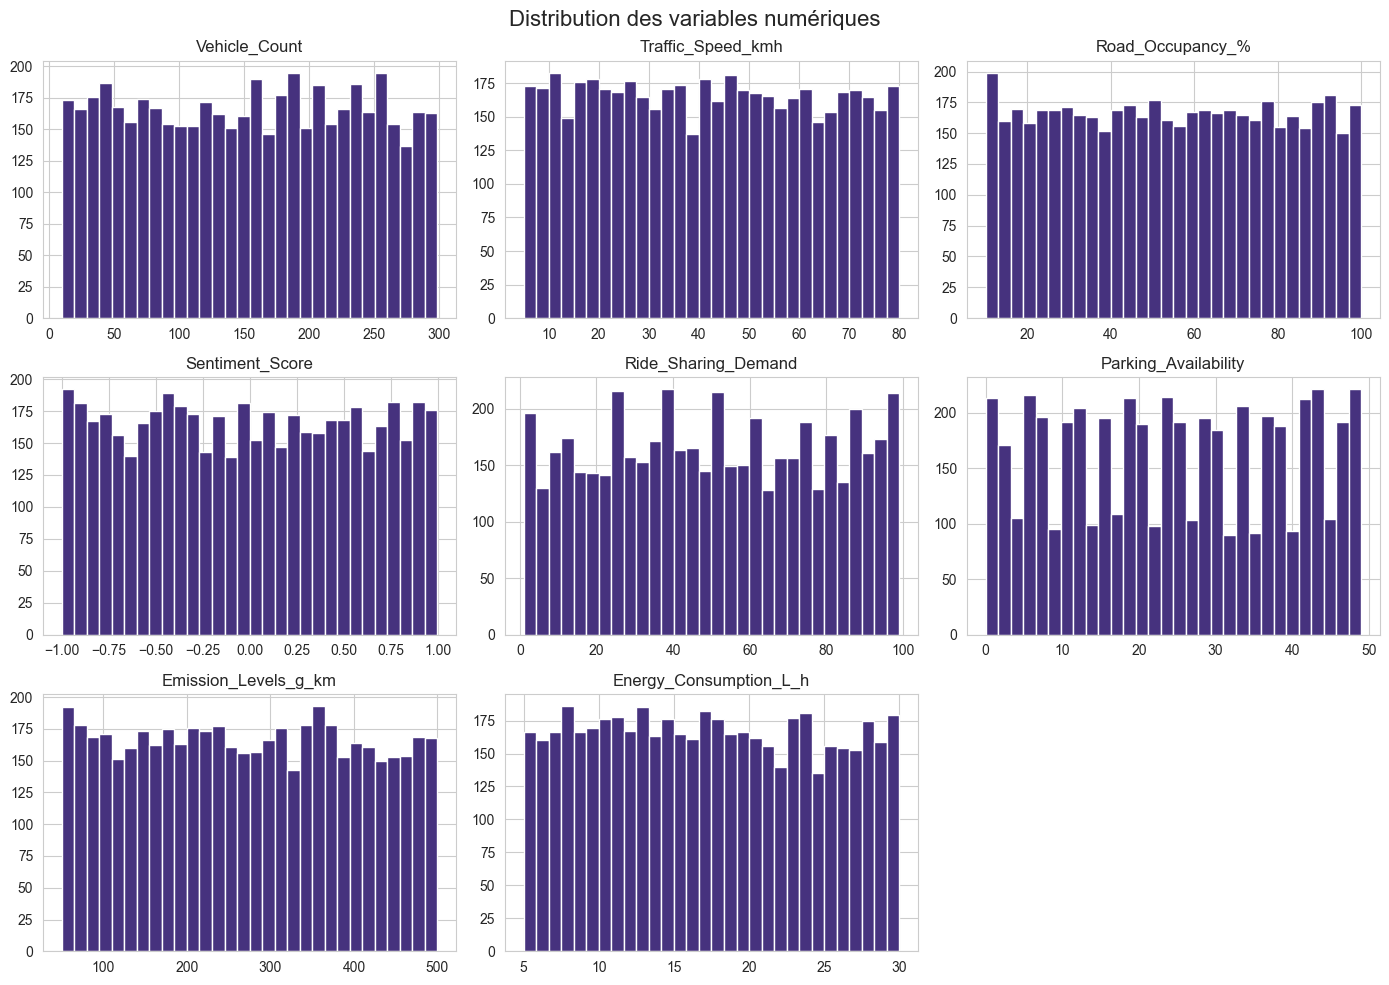

In [46]:
# Histogrammes de distribution
df[num_cols].hist(bins=30, figsize=(14, 10))
plt.suptitle("Distribution des variables numériques", fontsize=16)
plt.tight_layout()
plt.show()

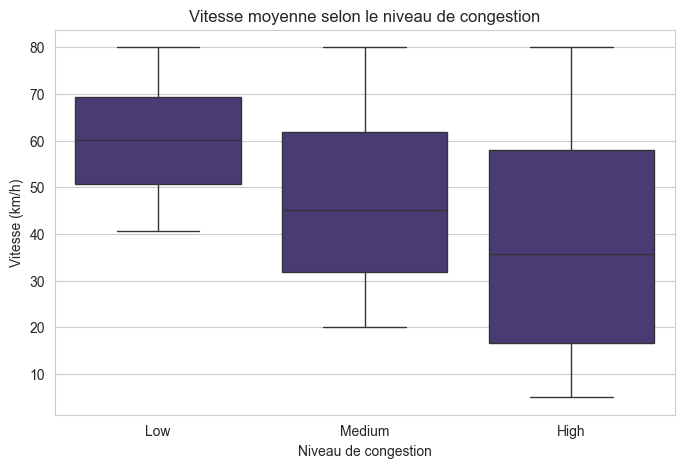

In [47]:
# 2.4 Boxplots : Vitesse vs Congestion
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Traffic_Condition", y="Traffic_Speed_kmh", order=['Low', 'Medium', 'High'])
plt.title("Vitesse moyenne selon le niveau de congestion")
plt.xlabel("Niveau de congestion")
plt.ylabel("Vitesse (km/h)")
plt.show()

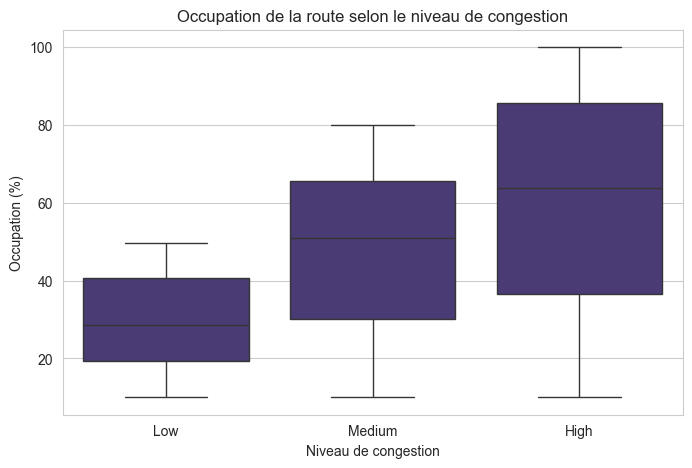

In [48]:
# Occupation de routes vs congestion
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Traffic_Condition", y="Road_Occupancy_%", order=['Low', 'Medium', 'High'])
plt.title("Occupation de la route selon le niveau de congestion")
plt.xlabel("Niveau de congestion")
plt.ylabel("Occupation (%)")
plt.show()

([0, 1, 2, 3],
 [Text(0, 0, 'Clear'),
  Text(1, 0, 'Rain'),
  Text(2, 0, 'Fog'),
  Text(3, 0, 'Snow')])

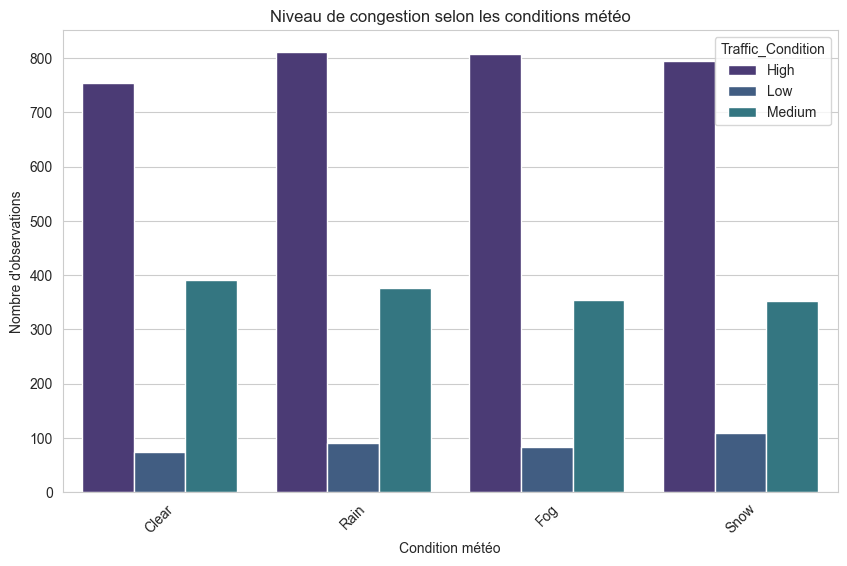

In [49]:
# Influence de la météo sur la congestion
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Weather_Condition", hue="Traffic_Condition")
plt.title("Niveau de congestion selon les conditions météo")
plt.xlabel("Condition météo")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=45)

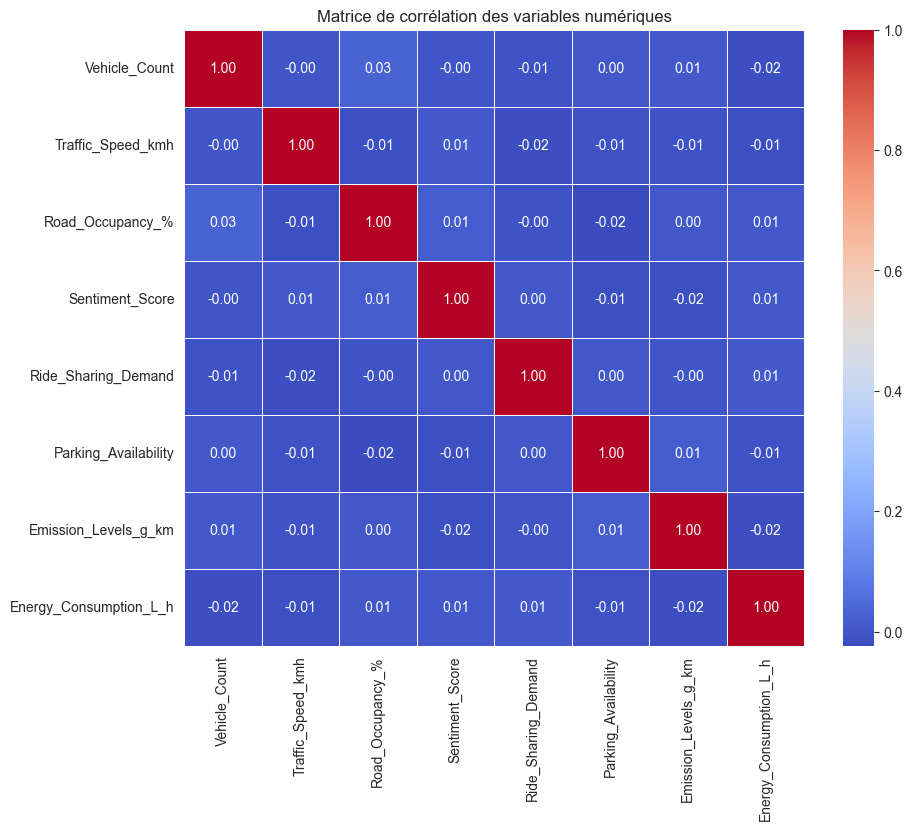

In [50]:
# Matrice de corrélation (Seaborn heatmap)
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

### FEATURE ENGINEERING

In [51]:
# Variables temporelles de base
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [52]:
# Signaux cycliques
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

In [53]:
# Moyennes glissantes sur 1 heure
df = df.sort_values('Timestamp')
df['vehicle_rolling_1h'] = df['Vehicle_Count'].rolling(window=12, min_periods=1).mean().shift(1)
df['speed_rolling_1h'] = df['Traffic_Speed_kmh'].rolling(window=12, min_periods=1).mean().shift(1)

In [54]:
df = df.dropna().reset_index(drop=True)
df['rain_weather_flag'] = df['Weather_Condition'].str.contains('Rain|Storm', na=False).astype(int)
df['accident_sentiment_interaction'] = df['Accident_Report'] * df['Sentiment_Score']

print(" Feature engineering terminé : 8 nouvelles variables créées")
df[['hour', 'is_weekend', 'vehicle_rolling_1h', 'rain_weather_flag']].head()

 Feature engineering terminé : 8 nouvelles variables créées


,hour,is_weekend,vehicle_rolling_1h,rain_weather_flag
0,0,0,205.000000,0
1,0,0,203.500000,1
2,0,0,219.666667,0
3,0,0,174.000000,0
4,0,0,152.000000,0


# 4. PRÉPARATION DES DONNÉES POUR LA MODÉLISATION

In [55]:
# Variables de classification
target = 'Traffic_Condition'

# Features
features = [
    'hour', 'day_of_week', 'is_weekend',
    'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%',
    'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability',
    'Emission_Levels_g_km', 'Energy_Consumption_L_h',
    'Accident_Report', 'vehicle_rolling_1h', 'speed_rolling_1h',
    'rain_weather_flag', 'accident_sentiment_interaction',
    'Weather_Condition', 'Traffic_Light_State'
]

X = df[features]
y = df[target]

In [56]:
# Split chronologique 
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Split temporel effectué : {len(X_train)} lignes entraînement | {len(X_test)} lignes test")

Split temporel effectué : 3999 lignes entraînement | 1000 lignes test


# 5. PIPELINE DE PRÉTRAITEMENT + MODÈLES

In [57]:
num_features = [
    'hour', 'day_of_week', 'is_weekend',
    'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%',
    'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability',
    'Emission_Levels_g_km', 'Energy_Consumption_L_h',
    'Accident_Report', 'vehicle_rolling_1h', 'speed_rolling_1h',
    'rain_weather_flag', 'accident_sentiment_interaction'
]

In [58]:
cat_features = ['Weather_Condition', 'Traffic_Light_State']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),  
            ("scaler", StandardScaler())
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_features)
    ]
)

In [59]:
# Modèle 1 : Régression Logistique
logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [60]:
# Modèle 2 : Random Forest
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])


# 6. ENTRAÎNEMENT ET ÉVALUATION

In [61]:
# Entraînement Logistic Regression
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
print("=== Rapport Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Rapport Logistic Regression ===
              precision    recall  f1-score   support

        High       0.82      0.87      0.85       631
         Low       0.79      0.66      0.72        70
      Medium       0.62      0.57      0.59       299

    accuracy                           0.77      1000
   macro avg       0.75      0.70      0.72      1000
weighted avg       0.76      0.77      0.76      1000



In [62]:
# Entraînement Random Forest
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\nResultat du Random Forest")
print(classification_report(y_test, y_pred_rf))


Resultat du Random Forest
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       631
         Low       1.00      0.97      0.99        70
      Medium       0.99      1.00      1.00       299

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000



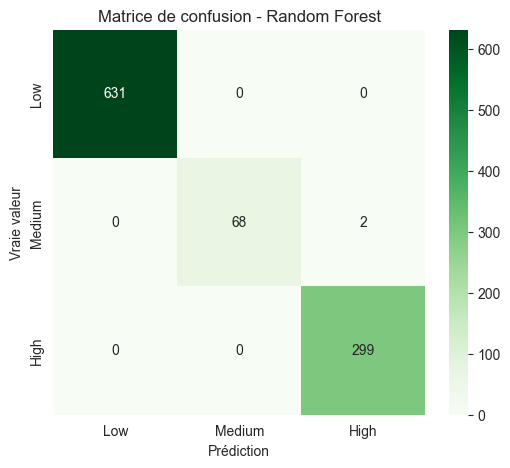

In [63]:
# Matrice de confusion Random Forest (meilleur modèle)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Prédiction")
plt.ylabel("Vraie valeur")
plt.show()

C:\Users\ariel\AppData\Local\Temp\ipykernel_26484\1002831455.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi, x='importance', y='feature', palette="viridis")


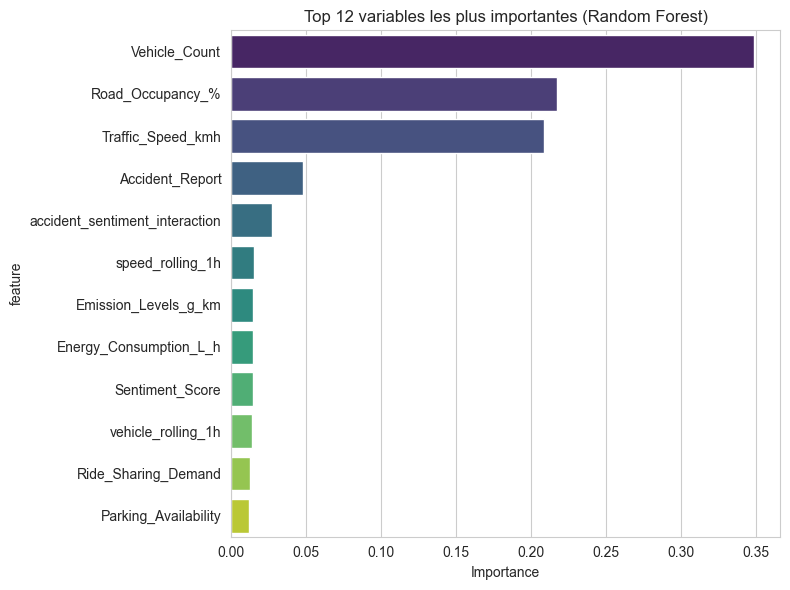

In [64]:
# Feature importance (seulement pour Random Forest)
feature_names = num_features + list(
    rf.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(cat_features)
)

importances = rf.named_steps["model"].feature_importances_
fi = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi = fi.sort_values('importance', ascending=False).head(12)

plt.figure(figsize=(8,6))
sns.barplot(data=fi, x='importance', y='feature', palette="viridis")
plt.title("Top 12 variables les plus importantes (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [65]:
import joblib
import os
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

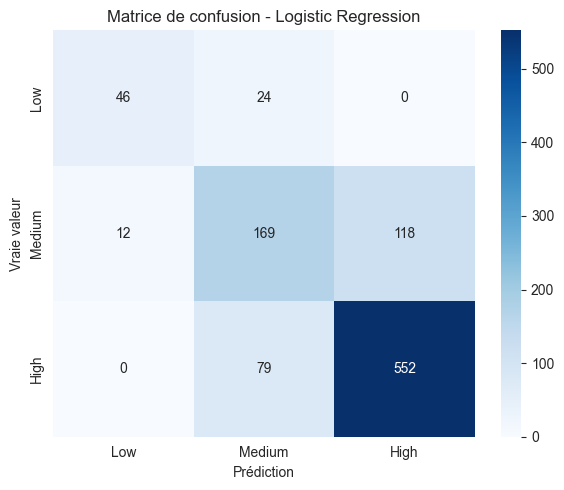

In [66]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)
plt.title("Matrice de confusion - Logistic Regression")
plt.xlabel("Prédiction")
plt.ylabel("Vraie valeur")
plt.tight_layout()
plt.show()

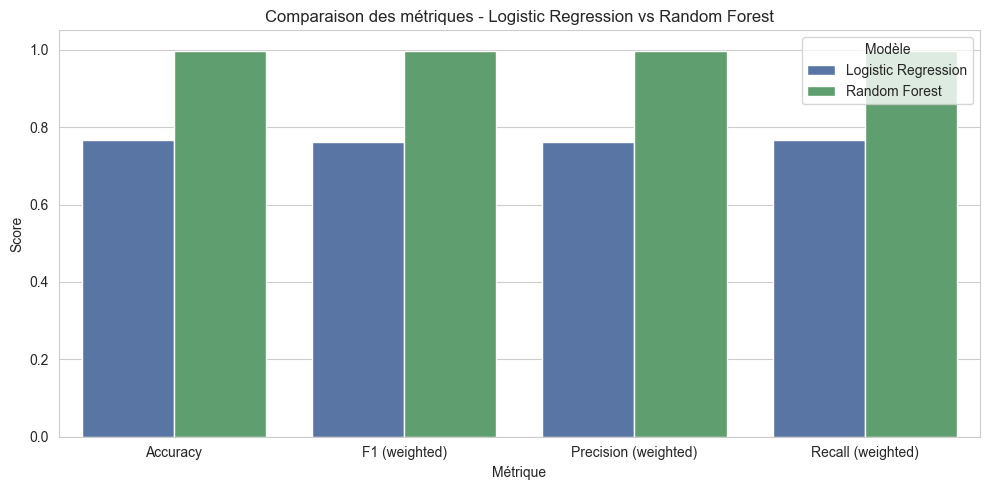

In [67]:

classes = ['Low', 'Medium', 'High']
average = 'weighted'

metrics_data = {
    'Modèle': ['Logistic Regression', 'Logistic Regression', 'Logistic Regression', 'Logistic Regression',
               'Random Forest',       'Random Forest',       'Random Forest',       'Random Forest'],
    'Métrique': ['Accuracy', 'F1 (weighted)', 'Precision (weighted)', 'Recall (weighted)'] * 2,
    'Score': [
        accuracy_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr, average=average),
        precision_score(y_test, y_pred_lr, average=average),
        recall_score(y_test, y_pred_lr, average=average),
        accuracy_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf, average=average),
        precision_score(y_test, y_pred_rf, average=average),
        recall_score(y_test, y_pred_rf, average=average),
    ]
}

metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=metrics_df,
    x='Métrique', y='Score', hue='Modèle',
    palette=['#4C72B0', '#55A868']
)
plt.title("Comparaison des métriques - Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(title='Modèle')
plt.tight_layout()
plt.show()

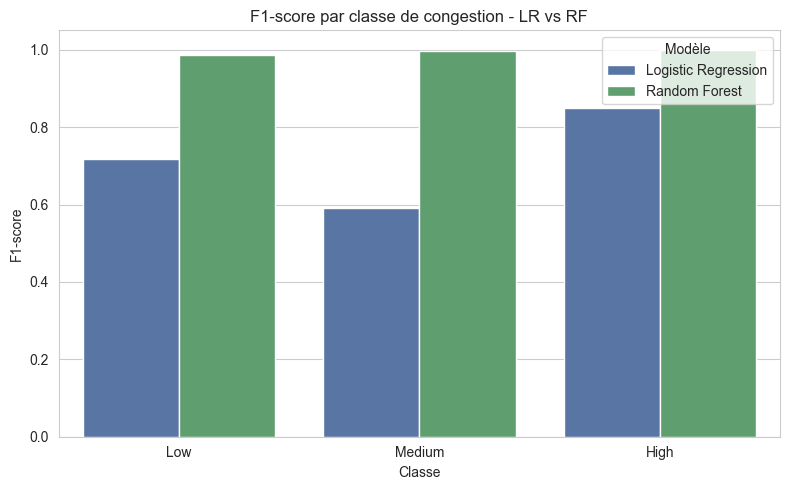

In [68]:
# Comparaison par classe : F1-score
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

f1_per_class = pd.DataFrame({
    'Classe': classes * 2,
    'Modèle': ['Logistic Regression'] * 3 + ['Random Forest'] * 3,
    'F1-score': [
        report_lr['Low']['f1-score'],
        report_lr['Medium']['f1-score'],
        report_lr['High']['f1-score'],
        report_rf['Low']['f1-score'],
        report_rf['Medium']['f1-score'],
        report_rf['High']['f1-score'],
    ]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=f1_per_class, x='Classe', y='F1-score', hue='Modèle',
            palette=['#4C72B0', '#55A868'])
plt.title("F1-score par classe de congestion - LR vs RF")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


In [69]:
best_f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
best_f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

best_model = rf if best_f1_rf >= best_f1_lr else logreg
best_model_name = "RandomForest" if best_f1_rf >= best_f1_lr else "LogisticRegression"

os.makedirs("models", exist_ok=True)
model_path = f"models/traffic_classifier_{best_model_name}.pkl"
joblib.dump(best_model, model_path)

print(f"Meilleur modèle : {best_model_name}")
print(f"  F1 LR  : {best_f1_lr:.4f}")
print(f"  F1 RF  : {best_f1_rf:.4f}")
print(f"Modèle sauvegardé -> {model_path}")

# Vérification du rechargement
loaded_model = joblib.load(model_path)
y_check = loaded_model.predict(X_test.iloc[:5])
print(f"Verification rechargement OK : {y_check.tolist()}")

Meilleur modèle : RandomForest
  F1 LR  : 0.7628
  F1 RF  : 0.9980
Modèle sauvegardé -> models/traffic_classifier_RandomForest.pkl
Verification rechargement OK : ['High', 'High', 'High', 'Medium', 'High']


In [70]:

acc_lr  = accuracy_score(y_test, y_pred_lr)
acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_lr   = f1_score(y_test, y_pred_lr, average='weighted')
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted')